In [9]:
using DataFrames, Parquet

In [2]:
using Images
using FileIO
using ProgressMeter

function load_tinyimagenet(root)
    files = String[]

    for (dir, _, fs) in walkdir(root)
        for f in fs
            endswith(f, ".JPEG") && push!(files, joinpath(dir, f))
        end
    end

    N = length(files)

    X = Array{Float32}(undef, 64, 64, 1, N)

    @show N

    @showprogress for (i, file) in enumerate(files)
        img = load(file)

        gray = Gray.(img)

        X[:, :, 1, i] .= Float32.(channelview(gray))
    end

    return X, files
end

load_tinyimagenet (generic function with 1 method)

In [6]:
imgs, _ = load_tinyimagenet("../../../../ImageNet")

N = 100000


Progress: 100%|█████████████████████████████████████████| Time: 0:00:05


(Float32[0.69803923 0.7019608 … 0.90588236 0.59607846; 0.6745098 0.6784314 … 0.8784314 0.5803922; … ; 0.40392157 0.4 … 0.2627451 0.3019608; 0.4117647 0.4117647 … 0.2627451 0.24313726;;;; 0.101960786 0.09803922 … 0.17254902 0.18039216; 0.12156863 0.10980392 … 0.16470589 0.16862746; … ; 0.007843138 0.011764706 … 0.25490198 0.22352941; 0.015686275 0.007843138 … 0.14509805 0.14509805;;;; 0.48235294 0.36078432 … 0.5803922 0.44313726; 0.34901962 0.4862745 … 0.5176471 0.47058824; … ; 0.6745098 0.6509804 … 0.89411765 0.8901961; 0.6156863 0.6862745 … 0.8784314 0.8745098;;;; … ;;;; 0.78431374 0.78039217 … 0.1764706 0.1882353; 0.7882353 0.7882353 … 0.18039216 0.15686275; … ; 0.5686275 0.5686275 … 0.2 0.19607843; 0.59607846 0.6117647 … 0.20392157 0.20392157;;;; 0.3529412 0.38431373 … 0.5411765 0.54509807; 0.33333334 0.3764706 … 0.5372549 0.5372549; … ; 0.25882354 0.28627452 … 0.39607844 0.46666667; 0.29803923 0.26666668 … 0.34509805 0.38431373;;;; 0.27058825 0.2901961 … 0.14117648 0.10980392; 0.22

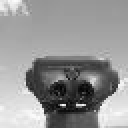

In [23]:
Gray.(imgs[:,:,1,37510])